In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('dataset.csv')
df.head(5)

,variant_id,variant_nama,satuan_display,tanggal,harga
0,1,Beras SPHP Bulog,kg,2026-01-01,0
1,52,Beras Medium,kg,2026-01-01,0
2,51,Beras Premium,kg,2026-01-01,0
3,14,Gula Pasir Curah,kg,2026-01-01,0
4,17,Minyak Goreng Sawit Kemasan Premium,lt,2026-01-01,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1819 entries, 0 to 1818
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   variant_id      1819 non-null   int64 
 1   variant_nama    1819 non-null   object
 2   satuan_display  1819 non-null   object
 3   tanggal         1819 non-null   object
 4   harga           1819 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 71.2+ KB


In [ ]:
df['harga'].isna().sum()

np.int64(0)

In [ ]:

df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.sort_values(by=['variant_id', 'tanggal']).reset_index(drop=True)
df['harga'] = df['harga'].replace(0, np.nan)

Linear Interpolation (If some data have a value 0, get a value for this data [day x] of data day x-1 and data day x+1)

In [ ]:
df['harga'] = df.groupby('variant_id')['harga'].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)

In [ ]:
df.head(5)

,variant_id,variant_nama,satuan_display,tanggal,harga
0,1,Beras SPHP Bulog,kg,2026-01-01,12376.000000
1,1,Beras SPHP Bulog,kg,2026-01-02,12376.000000
2,1,Beras SPHP Bulog,kg,2026-01-03,12369.666667
3,1,Beras SPHP Bulog,kg,2026-01-04,12363.333333
4,1,Beras SPHP Bulog,kg,2026-01-05,12357.000000


Exploratory Data Analysis (EDA)

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# sample_commodities = ['Beras Medium', 'Daging Ayam Ras', 'Telur Ayam Ras', 'Bawang Merah']

# for commodity in sample_commodities:
#     plt.figure(figsize=(14, 6))
#     plot_data = df[df['variant_nama'] == commodity]
#     plt.plot(plot_data['tanggal'], plot_data['harga'], marker='o', markersize=3)

#     plt.title(f'{commodity} Price Trends', fontsize=16)
#     plt.xlabel('Date', fontsize=12)
#     plt.ylabel('Price (IDR)', fontsize=12)
#     plt.legend()
#     plt.grid(True, linestyle='--', alpha=0.6)
#     plt.tight_layout()
#     plt.show()


Featured Engineering

Stationarity Test (ADF - Augmented Dickey-Fuller)

In [ ]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

def perform_adf_test(timeseries, name):
    result = adfuller(timeseries.dropna(), autolag='AIC')

    print(f'ADF Test Results untuk {name}:')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'P-value: {result[1]:.6f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'  {key}: {value:.3f}')

    # Kesimpulan
    if result[1] <= 0.05:
        print(f"✓ {name} adalah STATIONARY (p-value = {result[1]:.6f})")
        return True
    else:
        print(f"✗ {name} adalah NON-STATIONARY (p-value = {result[1]:.6f})")
        return False

# Test stasioneritas untuk setiap komoditas
print("="*70)
print("TESTING STASIONERITAS DATA HARGA")
print("="*70)

adf_results = {}
for commodity in df['variant_nama'].unique():
    commodity_data = df[df['variant_nama'] == commodity]['harga']
    is_stationary = perform_adf_test(commodity_data, commodity)

    # Re-run adfuller for storage (or optimize by storing result from function)
    res = adfuller(commodity_data.dropna(), autolag='AIC')
    adf_results[commodity] = {
        'stationary': is_stationary,
        'adf_stat': res[0],
        'p_value': res[1]
    }
    print("-"*70)

# Summary dalam bentuk tabel
adf_df = pd.DataFrame([
    {
        'Komoditas': commodity,
        'Stationary': results['stationary'],
        'ADF Statistic': results['adf_stat'],
        'P-value': results['p_value']
    }
    for commodity, results in adf_results.items()
])

print("\nRINGKASAN HASIL ADF TEST:")
display(adf_df)

TESTING STASIONERITAS DATA HARGA
ADF Test Results untuk Beras SPHP Bulog:
ADF Statistic: -3.615924
P-value: 0.005464
Critical Values:
  1%: -3.494
  5%: -2.889
  10%: -2.582
✓ Beras SPHP Bulog adalah STATIONARY (p-value = 0.005464)
----------------------------------------------------------------------
ADF Test Results untuk Cabai Merah Keriting:
ADF Statistic: -4.178866
P-value: 0.000715
Critical Values:
  1%: -3.495
  5%: -2.890
  10%: -2.582
✓ Cabai Merah Keriting adalah STATIONARY (p-value = 0.000715)
----------------------------------------------------------------------
ADF Test Results untuk Cabai Merah Besar:
ADF Statistic: -2.517553
P-value: 0.111262
Critical Values:
  1%: -3.498
  5%: -2.891
  10%: -2.583
✗ Cabai Merah Besar adalah NON-STATIONARY (p-value = 0.111262)
----------------------------------------------------------------------
ADF Test Results untuk Cabai Rawit Merah:
ADF Statistic: -1.480995
P-value: 0.542891
Critical Values:
  1%: -3.495
  5%: -2.890
  10%: -2.582
✗

,Komoditas,Stationary,ADF Statistic,P-value
0,Beras SPHP Bulog,True,-3.615924,0.005464
1,Cabai Merah Keriting,True,-4.178866,0.000715
2,Cabai Merah Besar,False,-2.517553,0.111262
3,Cabai Rawit Merah,False,-1.480995,0.542891
4,Bawang Merah,False,-2.482928,0.119684
5,Gula Pasir Curah,False,4.618356,1.000000
6,Minyak Goreng Sawit Curah,False,1.089309,0.995124
7,Minyak Goreng Sawit Kemasan Premium,False,1.980576,0.998647
8,Minyakita,False,-2.369990,0.150386
9,Daging Sapi Paha Belakang,False,-1.121932,0.706247


### 1st Order Differencing & Re-testing Stationarity
Karena mayoritas komoditas bersifat non-stasioner, kita akan melakukan differencing untuk menstabilkan mean dari time series.

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# 1. Identifikasi komoditas non-stasioner dari tes sebelumnya (adf_df)
non_stationary_commodities = adf_df[adf_df['Stationary'] == False]['Komoditas'].tolist()
stationary_commodities = adf_df[adf_df['Stationary'] == True]['Komoditas'].tolist()

# Inisialisasi kolom harga_final dengan harga asli
df['harga_final'] = df['harga'].copy()
df['diff_order'] = 0

print(f"Komoditas awal yang sudah stasioner: {stationary_commodities}")
print(f"Komoditas yang memerlukan differencing: {non_stationary_commodities}\n")

# 2. Loop untuk melakukan differencing hingga stasioner (maksimal 2 kali)
final_adf_results = []

for commodity in df['variant_nama'].unique():
    current_data = df[df['variant_nama'] == commodity].copy()
    series = current_data['harga']
    order = 0
    is_stat = adfuller(series.dropna())[1] <= 0.05

    # Lakukan differencing jika belum stasioner, maks 2nd order
    while not is_stat and order < 2:
        order += 1
        series = series.diff()
        p_val = adfuller(series.dropna())[1]
        is_stat = p_val <= 0.05
        print(f"Testing {commodity} - Order {order} Diff - P-value: {p_val:.6f}")

    # Simpan hasil ke dataframe utama
    df.loc[df['variant_nama'] == commodity, 'harga_final'] = series
    df.loc[df['variant_nama'] == commodity, 'diff_order'] = order

    final_adf_results.append({
        'Komoditas': commodity,
        'Final_Order': order,
        'Is_Stationary': is_stat,
        'P-value': adfuller(series.dropna())[1]
    })

print("\n" + "="*30)
print("RINGKASAN FINAL STATIONARITY")
print("="*30)
final_summary_df = pd.DataFrame(final_adf_results)
display(final_summary_df)

Komoditas awal yang sudah stasioner: ['Beras SPHP Bulog', 'Cabai Merah Keriting']
Komoditas yang memerlukan differencing: ['Cabai Merah Besar', 'Cabai Rawit Merah', 'Bawang Merah', 'Gula Pasir Curah', 'Minyak Goreng Sawit Curah', 'Minyak Goreng Sawit Kemasan Premium', 'Minyakita', 'Daging Sapi Paha Belakang', 'Telur Ayam Ras', 'Tepung Terigu', 'Daging Ayam Ras', 'Bawang Putih Honan', 'Kedelai Impor', 'Beras Premium', 'Beras Medium']

Testing Cabai Merah Besar - Order 1 Diff - P-value: 0.004138
Testing Cabai Rawit Merah - Order 1 Diff - P-value: 0.014985
Testing Bawang Merah - Order 1 Diff - P-value: 0.000111
Testing Gula Pasir Curah - Order 1 Diff - P-value: 0.009966
Testing Minyak Goreng Sawit Curah - Order 1 Diff - P-value: 0.000792
Testing Minyak Goreng Sawit Kemasan Premium - Order 1 Diff - P-value: 0.033253
Testing Minyakita - Order 1 Diff - P-value: 0.018452
Testing Daging Sapi Paha Belakang - Order 1 Diff - P-value: 0.003759
Testing Telur Ayam Ras - Order 1 Diff - P-value: 0.094

,Komoditas,Final_Order,Is_Stationary,P-value
0,Beras SPHP Bulog,0,True,5.463793e-03
1,Cabai Merah Keriting,0,True,7.153283e-04
2,Cabai Merah Besar,1,True,4.138153e-03
3,Cabai Rawit Merah,1,True,1.498479e-02
4,Bawang Merah,1,True,1.112985e-04
5,Gula Pasir Curah,1,True,9.965904e-03
6,Minyak Goreng Sawit Curah,1,True,7.917213e-04
7,Minyak Goreng Sawit Kemasan Premium,1,True,3.325268e-02
8,Minyakita,1,True,1.845198e-02
9,Daging Sapi Paha Belakang,1,True,3.759121e-03


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Fungsi untuk plotting otomatis menggunakan data stasioner terbaru
def plot_all_acf_pacf(dataframe, target_col='harga_final'):
    commodities = dataframe['variant_nama'].unique()

    for commodity in commodities:
        # Filter data per komoditas dan hapus NaN
        data_series = dataframe[dataframe['variant_nama'] == commodity][target_col].dropna()

        if len(data_series) > 0:
            fig, axes = plt.subplots(1, 2, figsize=(16, 4))

            # ACF
            plot_acf(data_series, ax=axes[0], title=f'ACF (Stationary): {commodity}', lags=20)
            # PACF
            plot_pacf(data_series, ax=axes[1], title=f'PACF (Stationary): {commodity}', lags=20, method='yw')

            plt.tight_layout()
            plt.show()
        else:
            print(f"Data tidak cukup untuk plotting: {commodity}")

# Menjalankan plot menggunakan kolom 'harga_final'
plot_all_acf_pacf(df)

## Time-based Features

In [ ]:
df['day'] = df['tanggal'].dt.day
df['day_of_week'] = df['tanggal'].dt.dayofweek
df['week_of_year'] = df['tanggal'].dt.isocalendar().week.astype(int)
df['is_month_start'] = df['tanggal'].dt.is_month_start.astype(int)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import pacf

def get_significant_lags(series, max_lags=14, alpha=0.05):
    """ Mendeteksi lag yang signifikan secara statistik berdasarkan PACF. """
    series_clean = series.dropna()
    actual_max_lags = min(max_lags, len(series_clean) // 2 - 1)
    if actual_max_lags < 1:
        return [1]

    pacf_values = pacf(series_clean, nlags=actual_max_lags, method='yw')
    conf_int = 1.96 / np.sqrt(len(series_clean))
    sig_lags = [i for i, val in enumerate(pacf_values) if i > 0 and abs(val) > conf_int]

    return sig_lags if sig_lags else [1]

def automated_feature_engineering_fixed(dataframe, target_col='harga_final', group_col='variant_id'):
    df_result = dataframe.copy()
    lag_config = {}
    global_lags = set() # SET UNTUK MENAMPUNG SEMUA LAG

    print("Mendeteksi lag signifikan per komoditas...")
    for variant_id in df_result[group_col].unique():
        mask = df_result[group_col] == variant_id
        commodity_series = df_result.loc[mask, target_col]
        sig_lags = get_significant_lags(commodity_series)
        lag_config[variant_id] = sig_lags
        global_lags.update(sig_lags) # Masukkan ke keranjang global

    # Urutkan lag agar rapi
    global_lags = sorted(list(global_lags))
    print(f"Lag global yang akan diekstrak untuk semua komoditas: {global_lags}")

    new_features = []
    print("Membuat fitur lag dan rolling statistics...")
    for variant_id in df_result[group_col].unique():
        mask = df_result[group_col] == variant_id
        subset = df_result.loc[mask].copy()

        # Gunakan global_lags agar jumlah kolom seragam untuk XGBoost
        for l in global_lags:
            subset[f'lag_{l}'] = subset[target_col].shift(l)

        subset['rolling_mean_3d'] = subset[target_col].rolling(window=3).mean().shift(1)
        subset['rolling_mean_7d'] = subset[target_col].rolling(window=7).mean().shift(1)

        new_features.append(subset)

    df_final = pd.concat(new_features).sort_index()

    cols_to_check = [f'lag_{l}' for l in global_lags] + ['rolling_mean_3d', 'rolling_mean_7d']

    initial_shape = df_final.shape[0]
    df_final = df_final.dropna(subset=cols_to_check).reset_index(drop=True)

    final_shape = df_final.shape[0]
    print(f"Feature Engineering selesai. Baris tersisa: {final_shape} (Dibuang karena pergeseran waktu: {initial_shape - final_shape})")

    return df_final, lag_config

# Eksekusi Pipeline
df_fe, final_lag_config = automated_feature_engineering_fixed(df)

Mendeteksi lag signifikan per komoditas...
Lag global yang akan diekstrak untuk semua komoditas: [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 14]
Membuat fitur lag dan rolling statistics...
Feature Engineering selesai. Baris tersisa: 1565 (Dibuang karena pergeseran waktu: 254)


In [ ]:
df_fe.sample()

,variant_id,variant_nama,satuan_display,tanggal,harga,harga_final,diff_order,day,day_of_week,week_of_year,...,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_11,lag_14,rolling_mean_3d,rolling_mean_7d
638,16,Minyak Goreng Sawit Curah,lt,2026-04-10,19308.0,25.0,1,10,4,15,...,14.75,14.75,14.75,14.75,42.0,-25.0,1.0,59.0,48.0,29.0


In [ ]:
for variant_id, lags in final_lag_config.items():
    commodity_name = df[df['variant_id'] == variant_id]['variant_nama'].iloc[0]
    print(f"  {commodity_name}: {lags}")

  Beras SPHP Bulog: [1, 2]
  Cabai Merah Keriting: [1, 2, 3, 4]
  Cabai Merah Besar: [1, 2, 4, 5, 6, 7]
  Cabai Rawit Merah: [1]
  Bawang Merah: [1]
  Gula Pasir Curah: [1, 2, 3]
  Minyak Goreng Sawit Curah: [1]
  Minyak Goreng Sawit Kemasan Premium: [1, 2, 14]
  Minyakita: [1, 2, 7, 11]
  Daging Sapi Paha Belakang: [1, 3, 6, 8, 9, 14]
  Telur Ayam Ras: [1]
  Tepung Terigu: [1, 5, 14]
  Daging Ayam Ras: [1, 6, 7]
  Bawang Putih Honan: [1]
  Kedelai Impor: [1]
  Beras Premium: [1]
  Beras Medium: [1, 9, 14]


In [ ]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   variant_id       1565 non-null   int64         
 1   variant_nama     1565 non-null   object        
 2   satuan_display   1565 non-null   object        
 3   tanggal          1565 non-null   datetime64[ns]
 4   harga            1565 non-null   float64       
 5   harga_final      1565 non-null   float64       
 6   diff_order       1565 non-null   int64         
 7   day              1565 non-null   int32         
 8   day_of_week      1565 non-null   int32         
 9   week_of_year     1565 non-null   int64         
 10  is_month_start   1565 non-null   int64         
 11  is_weekend       1565 non-null   int64         
 12  lag_1            1565 non-null   float64       
 13  lag_2            1565 non-null   float64       
 14  lag_3            1565 non-null   float64

In [ ]:
df_final = df_fe.round(4)

In [ ]:
df_final.sample(1)

,variant_id,variant_nama,satuan_display,tanggal,harga,harga_final,diff_order,day,day_of_week,week_of_year,...,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_11,lag_14,rolling_mean_3d,rolling_mean_7d
1454,51,Beras Premium,kg,2026-03-30,15345.0,-4.0,1,30,0,14,...,7.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.6667,-3.6667,-0.5714


In [ ]:
df_final.to_csv('dataset_transformed.csv')

### Visualisasi untuk Laporan Eksperimen
Bagian ini menghasilkan grafik untuk memvalidasi proses stasioneritas dan relevansi fitur.

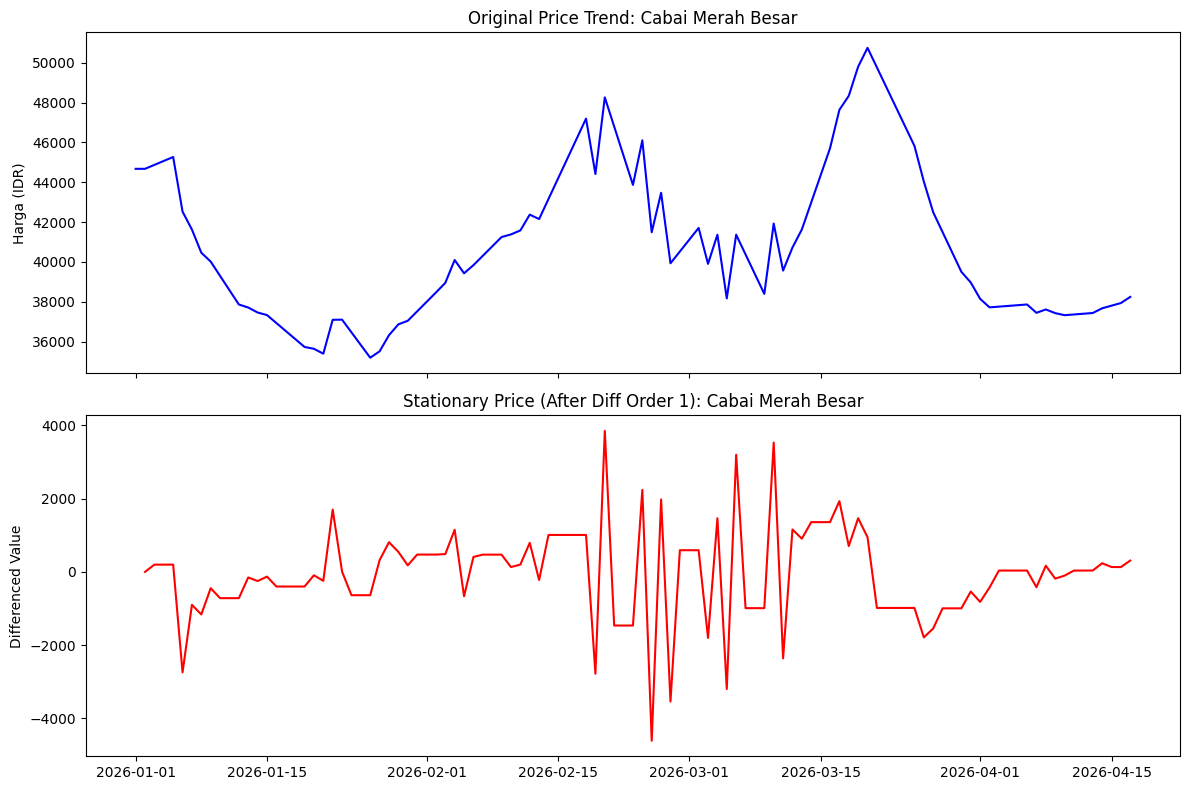

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualisasi Perbandingan Harga Asli vs Stasioner (Sample 1 Komoditas)
sample_com = df['variant_nama'].unique()[2] # Ambil Cabai Merah Besar sebagai contoh
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

subset_orig = df[df['variant_nama'] == sample_com]
ax1.plot(subset_orig['tanggal'], subset_orig['harga'], color='blue')
ax1.set_title(f'Original Price Trend: {sample_com}')
ax1.set_ylabel('Harga (IDR)')

subset_stat = df[df['variant_nama'] == sample_com]
ax2.plot(subset_stat['tanggal'], subset_stat['harga_final'], color='red')
ax2.set_title(f'Stationary Price (After Diff Order {subset_stat["diff_order"].iloc[0]}): {sample_com}')
ax2.set_ylabel('Differenced Value')

plt.tight_layout()
plt.show()

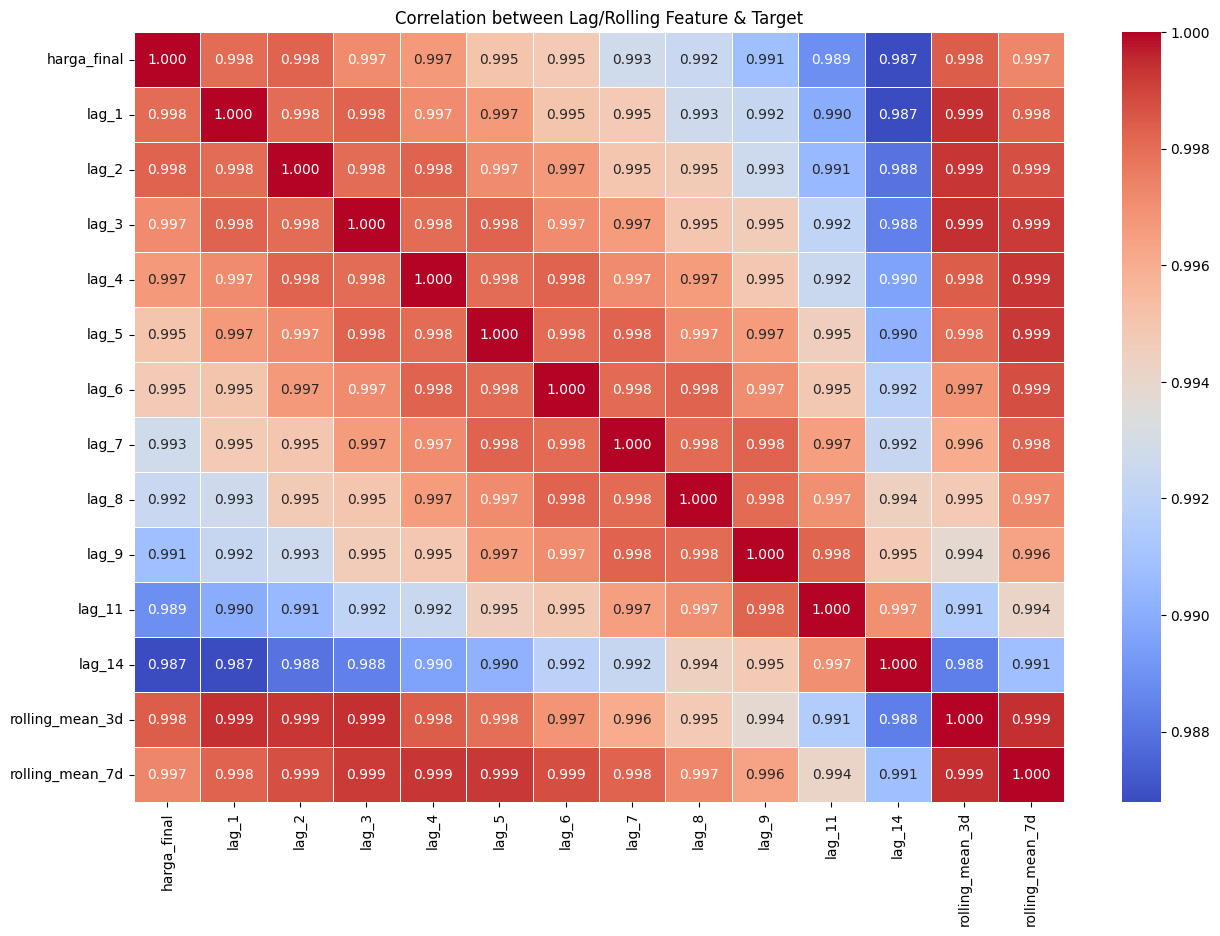

In [ ]:
# 2. Heatmap Korelasi Fitur
plt.figure(figsize=(15, 10))
corr_cols = [col for col in df_final.columns if 'lag_' in col or 'rolling_' in col or col == 'harga_final']
correlation_matrix = df_final[corr_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Correlation between Lag/Rolling Feature & Target')
plt.show()

Grafik di atas membantu menjelaskan:
- **Trend Removal**: Bahwa data sekarang berfluktuasi di sekitar angka nol (mean konstan).
- **Feature Strength**: Lag mana yang memiliki korelasi tertinggi dengan harga hari ini.